In [9]:
# 1. Load and inspect data
import pandas as pd
df = pd.read_csv("C:\\Users\\rohin\\Sucide Project\\Feature Engineering\\final_model_dataset_FEATURES.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 19 columns):
 #   Column                                                                       Non-Null Count  Dtype  
---  ------                                                                       --------------  -----  
 0   Year                                                                         25 non-null     int64  
 1   AlcoholConsumption                                                           25 non-null     float64
 2   HomicideRate                                                                 25 non-null     float64
 3   GDP_per_capita                                                               25 non-null     float64
 4   Unemployment, total (% of total labor force) (modeled ILO estimate)_x        25 non-null     float64
 5   SuicideRate                                                                  25 non-null     float64
 6   AlcoholConsumption_lag1                     

,Year,AlcoholConsumption,HomicideRate,GDP_per_capita,"Unemployment, total (% of total labor force) (modeled ILO estimate)_x",SuicideRate,AlcoholConsumption_lag1,HomicideRate_lag1,GDP_per_capita_lag1,"Unemployment, total (% of total labor force) (modeled ILO estimate)_x_lag1",AlcoholConsumption_lag2,HomicideRate_lag2,GDP_per_capita_lag2,"Unemployment, total (% of total labor force) (modeled ILO estimate)_x_lag2",AlcoholConsumption_roll3,HomicideRate_roll3,GDP_per_capita_roll3,"Unemployment, total (% of total labor force) (modeled ILO estimate)_x_roll3",Year_scaled
count,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000
mean,2012.000000,8.289990,20.523564,6072.452899,25.815480,18.194975,8.327997,21.822722,5940.230337,25.397320,8.366005,23.121881,5808.007775,25.021960,8.321112,21.889374,5921.164799,25.405680,12.000000
std,7.359801,0.288134,12.800318,1506.921621,3.813187,2.800270,0.282299,13.580023,1607.376854,3.536463,0.270842,14.194000,1691.178707,3.284664,0.256742,13.224231,1558.809641,3.479509,7.359801
min,2000.000000,7.791870,12.533244,2688.236760,22.287000,13.132524,7.791870,12.533244,2688.236760,22.287000,7.791870,12.533244,2688.236760,22.287000,7.791870,12.533244,2917.745205,22.339333,0.000000
25%,2006.000000,8.239292,13.446773,5651.205852,22.605000,16.074981,8.248683,13.508287,5580.603831,22.605000,8.336959,13.510317,5221.463337,22.605000,8.274978,13.524487,5711.907635,22.622000,6.000000
50%,2012.000000,8.397732,13.955669,6523.410978,24.683000,18.186891,8.402676,14.266698,6374.705600,24.639000,8.421343,14.477758,6184.754743,24.561000,8.399800,14.045817,6319.238153,24.642333,12.000000
75%,2018.000000,8.451479,17.915438,6843.399419,27.035000,20.140313,8.451979,18.905256,6843.399419,26.906000,8.470212,44.530240,6843.399419,26.536000,8.445688,27.116978,6688.741442,26.825667,18.000000
max,2024.000000,8.742056,47.472567,8646.055711,34.007000,22.295801,8.742056,47.472567,8646.055711,34.007000,8.742056,47.472567,8646.055711,34.007000,8.655983,45.858397,8232.168151,33.124333,24.000000


In [10]:
# 2. Feature/target split
X = df.drop(columns=['Year','SuicideRate'])
y = df['SuicideRate']

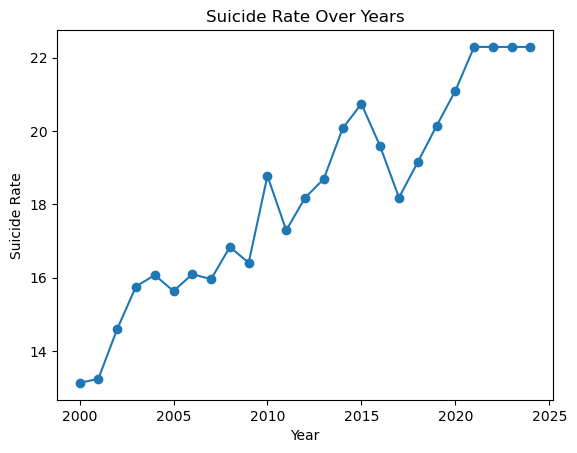

In [11]:
# 3. Exploratory plots (for demonstration, not embedded here)
import matplotlib.pyplot as plt
plt.plot(df['Year'], df['SuicideRate'], marker='o')
plt.title("Suicide Rate Over Years")
plt.xlabel("Year"); plt.ylabel("Suicide Rate")
plt.show()

In [12]:
# 4. Correlation matrix to check multicollinearity
corr = df.drop(columns=['Year','SuicideRate']).corr()
print("Correlation with target:\n", df.corr()['SuicideRate'].sort_values(ascending=False))

Correlation with target:
 SuicideRate                                                                    1.000000
Year                                                                           0.959193
Year_scaled                                                                    0.959193
Unemployment, total (% of total labor force) (modeled ILO estimate)_x          0.874200
Unemployment, total (% of total labor force) (modeled ILO estimate)_x_roll3    0.861950
Unemployment, total (% of total labor force) (modeled ILO estimate)_x_lag1     0.840456
Unemployment, total (% of total labor force) (modeled ILO estimate)_x_lag2     0.809420
GDP_per_capita_lag2                                                            0.681883
GDP_per_capita_roll3                                                           0.664069
GDP_per_capita_lag1                                                            0.616866
GDP_per_capita                                                                 0.566673
Homici

In [13]:
# 5. Split data by time: use earliest 80% for training, latest 20% for test (for example)
split_idx = int(len(df)*0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [7]:
import sys
sys.executable


'C:\\Users\\rohin\\anaconda3\\python.exe'

In [8]:
!pip install xgboost


   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
    --------------------------------------- 1.3/72.0 MB 7.5 MB/s eta 0:00:10
   - -------------------------------------- 2.6/72.0 MB 6.9 MB/s eta 0:00:11
   -- ------------------------------------- 4.2/72.0 MB 6.8 MB/s eta 0:00:10
   --- ------------------------------------ 5.5/72.0 MB 6.7 MB/s eta 0:00:10
   --- ------------------------------------ 6.8/72.0 MB 6.8 MB/s eta 0:00:10
   ---- ----------------------------------- 8.4/72.0 MB 6.8 MB/s eta 0:00:10
   ----- ---------------------------------- 9.7/72.0 MB 6.7 MB/s eta 0:00:10
   ------ --------------------------------- 11.3/72.0 MB 6.8 MB/s eta 0:00:09
   ------ --------------------------------- 12.6/72.0 MB 6.7 MB/s eta 0:00:09
   ------- -------------------------------- 14.2/72.0 MB 6.7 MB/s eta 0:00:09
   -------- ------------------------------- 15.5/72.0 MB 6.7 MB/s eta 0:00:09
   --------- ------------------------------ 17.0/72.0 MB 6.7 MB/s eta 0:00:09
 

In [16]:
# 6. Define models: Linear, Ridge, Lasso, RandomForest, XGBoost

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

models = {
    'Linear': LinearRegression(),

    'Ridge': Ridge(alpha=1.0),

    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=0.5, max_iter=10000, random_state=0))
    ]),

    'RandomForest': RandomForestRegressor(
        n_estimators=100,
        random_state=0
    ),

    'XGBoost': xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0
    )
}

In [17]:
# 7. Train models on training data
for name, model in models.items():
    model.fit(X_train, y_train)

In [18]:
# 8. Evaluate on test data
from sklearn.metrics import mean_squared_error, r2_score

for name, model in models.items():
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"{name}: MSE = {mse:.3f}, R^2 = {r2:.3f}")


Linear: MSE = 572.564, R^2 = -2499.797
Ridge: MSE = 16.150, R^2 = -69.540
Lasso: MSE = 3.095, R^2 = -12.518
RandomForest: MSE = 10.163, R^2 = -43.388
XGBoost: MSE = 11.115, R^2 = -47.546


In [19]:
# 9. (Optional) Time-series cross-validation to tune model hyperparameters
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

tscv = TimeSeriesSplit(n_splits=5)
param_grid = {'alpha': [0.01, 0.1, 1, 10]}
ridge_search = GridSearchCV(Ridge(), param_grid, cv=tscv, scoring='neg_mean_squared_error')
ridge_search.fit(X_train, y_train)
print("Best Ridge alpha:", ridge_search.best_params_)


Best Ridge alpha: {'alpha': 10}
